In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

os.environ["JAX_PLATFORM_NAME"] = "cpu"
import jax
import jax.numpy as jnp
import jax_cosmo as jc

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph, data, diagnostics

# print(jax.devices("gpu"))
print(jax.default_backend())

cpu


In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# i_snapshots = None
i_snapshots = np.arange(-4, 0)

In [7]:
out_dict = camels.load_CV_snapshots(
    "CV_0",
    # "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

Loaded /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5


In [ ]:
# Compute the tidal field at the position of each particle
kk = jnp.where(kk == 0, 1., kk)
T_xx = cic_read(jnp.fft.ifftn(-(kvec[0]**2) * delta_k / kk).real, pos)
T_yy = cic_read(jnp.fft.ifftn(-(kvec[1]**2) * delta_k / kk).real, pos)
T_zz = cic_read(jnp.fft.ifftn(-(kvec[2]**2) * delta_k / kk).real, pos)
T_xy = cic_read(jnp.fft.ifftn(-(kvec[0] * kvec[1]) * delta_k / kk).real, pos)
T_xz = cic_read(jnp.fft.ifftn(-(kvec[0] * kvec[2]) * delta_k / kk).real, pos)
T_yz = cic_read(jnp.fft.ifftn(-(kvec[1] * kvec[2]) * delta_k / kk).real, pos)

# rotationally invariant features per particle
delta = cic_read(rho, pos) - 0.99

T = jnp.stack([                      # shape (N,3,3)
        jnp.stack([T_xx, T_xy, T_xz], -1),
        jnp.stack([T_xy, T_yy, T_yz], -1),
        jnp.stack([T_xz, T_yz, T_zz], -1)], -2)

eigval, eigvec = jnp.linalg.eigh(T)  # symmetric, so eigh is fine

features = jnp.concatenate([jnp.log1p(delta)[...,None],
                            jnp.arcsinh(eigval),
                            eigvec.reshape([-1,9])], -1)


In [ ]:
scales, particle_features, field_features = camels.preprocess_snapshots(out_dict)

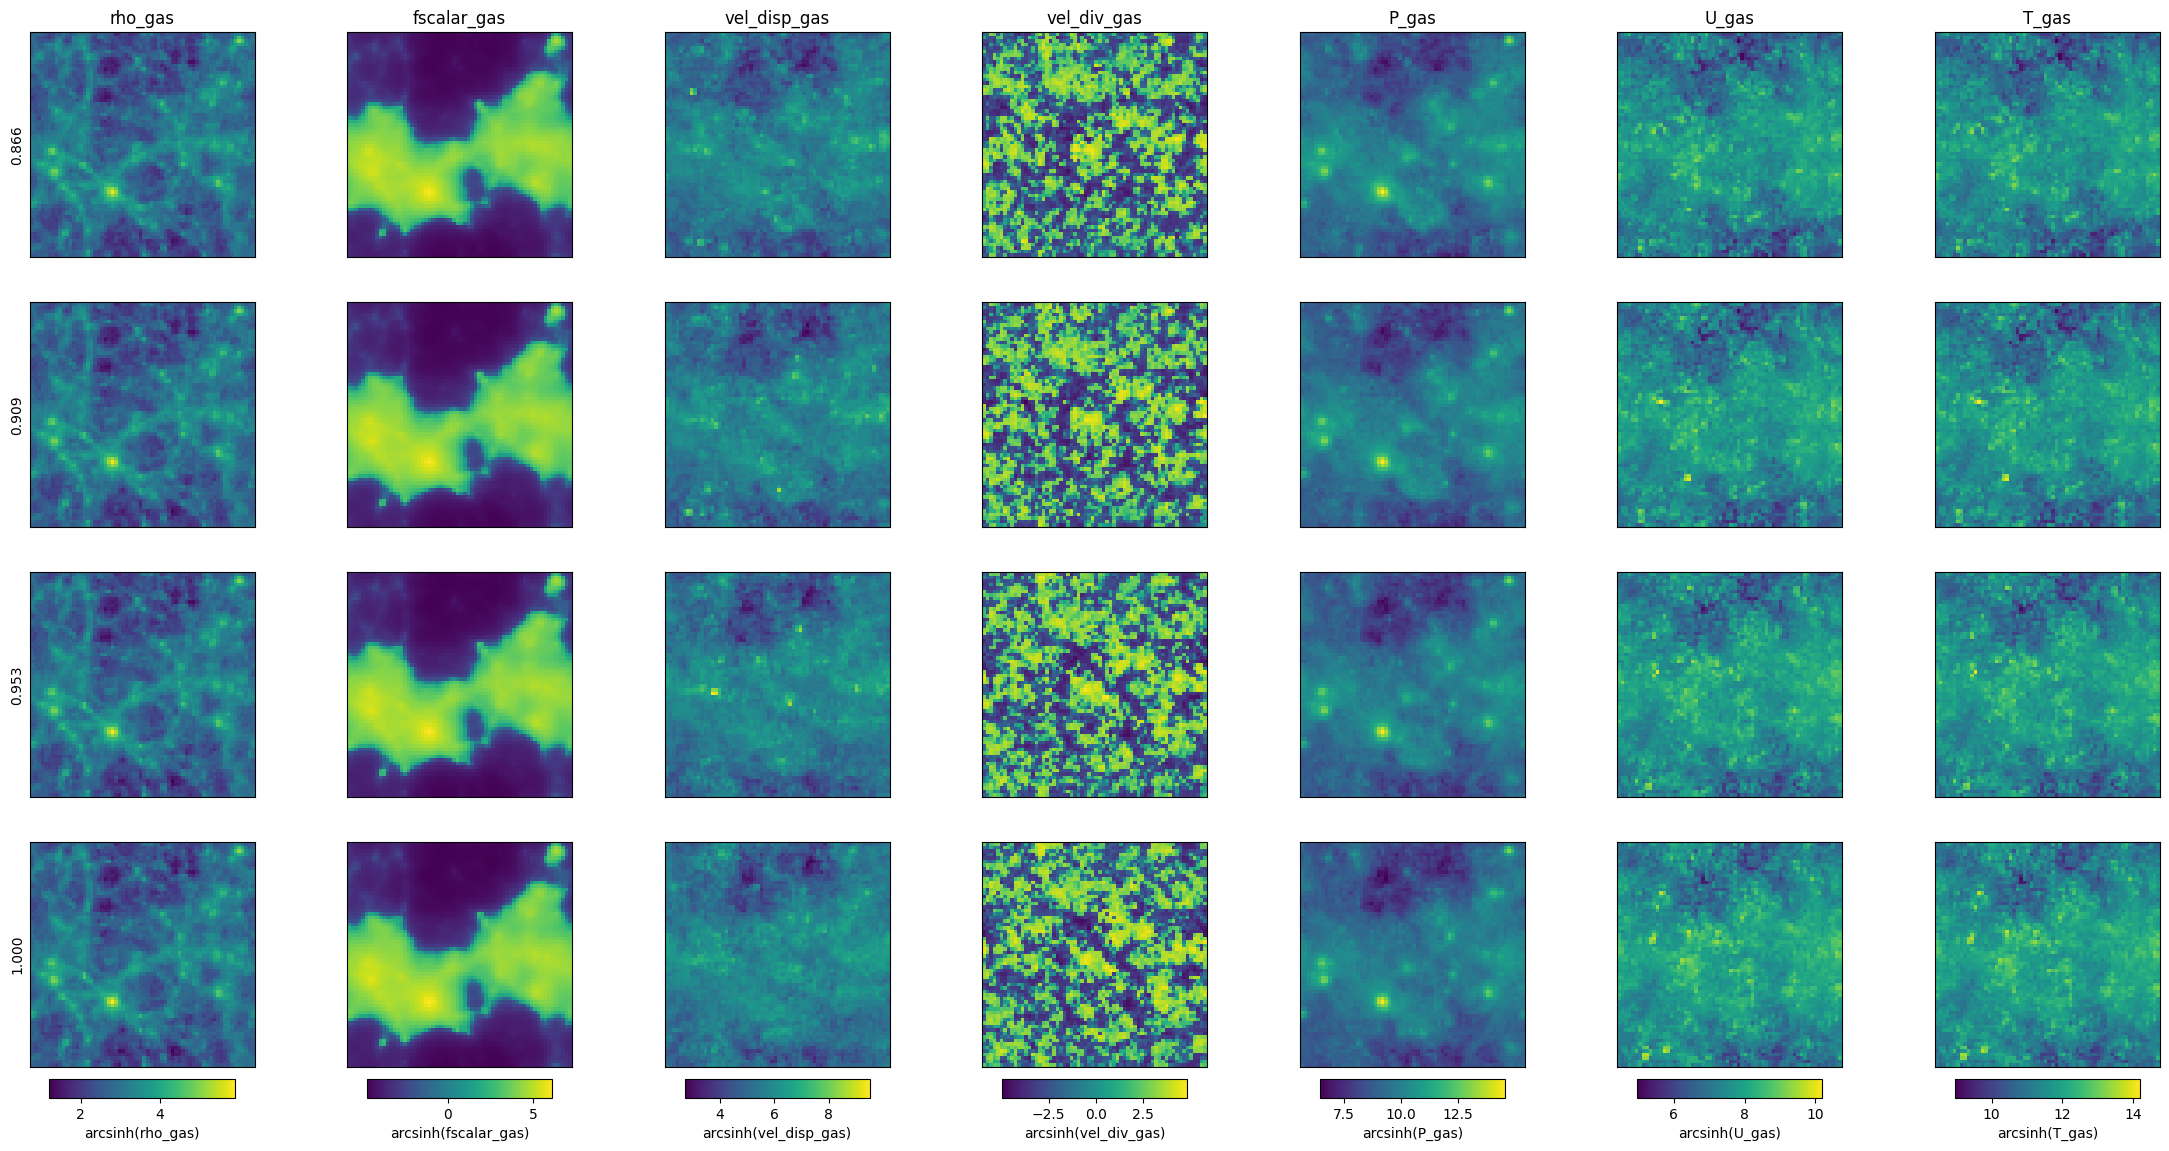

In [8]:
scales, particle_features, field_features = camels.preprocess_snapshots(out_dict)
plotting.plot_gas_features(scales, field_features)

# OLD

In [30]:
%%timeit
out_dict = camels.load_CV_snapshots(
    "CV_0",
    # "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
    # CODE="Astrid",
    # CODE="IllustrisTNG",
)

Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5
Loading /c

In [7]:
out_dict.keys()

dict_keys(['scales', 'dm_ids', 'dm_poss', 'dm_vels', 'dm_masss', 'h_poss', 'h_masss', 'h_lens', 'h_ids', 'gas_ids', 'gas_poss', 'gas_vels', 'gas_masss', 'gas_rhos', 'gas_Us', 'gas_Ts', 'gas_Ps', 'masses', 'cosmo', 'mesh_per_dim'])

In [12]:
cosmo = jc.Planck15(
        Omega_c=0.3 - 0.049,
        Omega_b=0.049,
        n_s=0.9624,
        h=0.6711,
        sigma8=0.8,
    )

In [12]:
with h5py.File('./temp/data.h5', 'w') as f:
    for key, array in out_dict.items():
        print(key)
        try:
            f.create_dataset(key, data=array)
            print(key, "successful")
        except ValueError:
            print(key, "failed")

scales
scales successful
dm_ids
dm_ids successful
dm_poss
dm_poss successful
dm_vels
dm_vels successful
dm_masss
dm_masss successful
h_poss
h_poss failed
h_masss
h_masss failed
h_lens
h_lens failed
h_ids
h_ids failed
gas_ids
gas_ids successful
gas_poss
gas_poss successful
gas_vels
gas_vels successful
gas_masss
gas_masss successful
gas_rhos
gas_rhos successful
gas_Us
gas_Us successful
gas_Ts
gas_Ts successful
gas_Ps
gas_Ps successful
masses
masses successful
mesh_per_dim
mesh_per_dim successful


In [24]:
with h5py.File('./temp/data.h5', 'r') as f:
    for key in f.keys():
        # print(key)
        try:
            temp = f[key][:]
        except:
            print(key, "failed")

mesh_per_dim failed


In [19]:
with h5py.File('./temp/data.h5', 'r') as f:
    for 
    # dm_poss = f["dm_poss"]
    # print(dm_poss)

<HDF5 dataset "dm_poss": shape (4, 262144, 3), type "<f4">


In [26]:
with h5py.File("/cluster/work/refregier/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-4 -3 -2 -1].h5", 'r') as f:
    for key in f.keys():
        print(key)

dm_ids
dm_masss
dm_poss
dm_vels
gas_Ps
gas_Ts
gas_Us
gas_ids
gas_masss
gas_poss
gas_rhos
gas_vels
masses
mesh_per_dim
scales


In [19]:
dm_poss.shape

(4, 262144, 3)